# PINN: Trajektorie lernen → danach Wurf klassifizieren (clean & noisy)

Zielsetzung:
- Das PINN lernt die Trajektorie \((x(t), y(t))\) aus Eingaben `[theta, v0, hs, t]`.
- Nach dem Training wird jede vorausgesagte Trajektorie deterministisch klassifiziert zu.
- Auswertung: Loss-Kurven, Beispieltrajektorien (Datensatz vs. Vorhersage), wurfweise Konfusionsmatrix & Metriken.

Klassifikations-Heuristik aus der vorhergesagten Trajektorie:
Beurteilt den Wurf am Korb-Plane `x = l`. Falls `max(x_pred) < l`, gilt zu kurz. Ansonsten wird `y_pred` bei `x=l` linear interpoliert. Liegt der Ballmittelpunkt im Fenster `[hKorb - (Rr - Rb), hKorb + (Rr - Rb)]`, werten wir als Treffer, sonst zu lang.


In [1]:
import os, sys, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
print('Python', sys.version)
print('Torch', torch.__version__)


Python 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
Torch 2.6.0+cpu


In [2]:
class DataGen:
    def __init__(self, hs=2.13, l=4.115, hKorb=3.048, Rr=0.2286, Rb=0.1219, g=9.807):
        self.params = {'l': l, 'hKorb': hKorb, 'Rr': Rr, 'Rb': Rb, 'g': g}
        self.hs = hs
        self.wurf_hoehe = 1.25 * hs
    def wurfgeschwindigkeit(self, theta):
        l = self.params['l']; h = self.params['hKorb'] - self.wurf_hoehe; g = self.params['g']
        return (l/np.cos(theta)) * np.sqrt(g / (2 * (l*np.tan(theta) - h)))
    def wurftrajektorien(self, theta, v0, t):
        g = self.params['g']; vx = v0*np.cos(theta); vy = v0*np.sin(theta)
        x = vx * t; y = vy * t - 0.5 * g * t**2 + self.wurf_hoehe
        return x, y
    def generate_dataset(self, base_theta_deg=48.43, n=150, with_noise=False):
        base_theta = np.deg2rad(base_theta_deg); base_v0 = self.wurfgeschwindigkeit(base_theta)
        cats = {0:{'theta':(-0.15,-0.05),'v0':(-0.5,-0.2)}, 1:{'theta':(-0.03,0.03),'v0':(-0.1,0.1)}, 2:{'theta':(0.06,0.15),'v0':(0.3,0.5)}}
        rows=[]
        for label,var in cats.items():
            rows += self._gen(base_theta, base_v0, var, label, n)
        df = pd.DataFrame(rows)
        if with_noise:
            df = self.full_noise_pipeline(df)
        return df
    def _gen(self, theta_base, v0_base, var, label, n):
        g = self.params['g']; rows=[]
        for _ in range(n):
            theta = theta_base + np.random.uniform(*var['theta'])
            v0 = v0_base + np.random.uniform(*var['v0'])
            T = 2 * v0 * np.sin(theta) / g
            t_vals = np.linspace(0, T, 50)
            x, y = self.wurftrajektorien(theta, v0, t_vals)
            wid = str(np.random.randint(1e9))
            for xi, yi, ti in zip(x, y, t_vals):
                rows.append({'x':xi,'y':yi,'theta':theta,'v0':v0,'t':ti,'label':label,'wurf_id':wid})
        return rows
    def add_position_noise(self, df, std_x=0.1, std_y=0.1):
        d = df.copy(); d['x'] += np.random.normal(0,std_x,len(df)); d['y'] += np.random.normal(0,std_y,len(df)); return d
    def full_noise_pipeline(self, df):
        return self.add_position_noise(df)


In [3]:
class FreeThrowPINNModel(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, 2)
        )
    def forward(self, theta, v0, hs, t):
        if theta.dim()==1: theta = theta.unsqueeze(1)
        if v0.dim()==1: v0 = v0.unsqueeze(1)
        if hs.dim()==1: hs = hs.unsqueeze(1)
        if t.dim()==1: t = t.unsqueeze(1)
        inp = torch.cat([theta, v0, hs, t], dim=1)
        out = self.net(inp)
        return out[:,0:1], out[:,1:2]

def df_to_tensors(df, hs_val=2.13, device='cpu'):
    d = df.copy()
    if 't' not in d.columns:
        d['vx'] = d['v0'] * np.cos(d['theta']).astype(float)
        d['vx'] = d['vx'].replace(0, 1e-8)
        d['t'] = d['x']/d['vx']
    d['t'] = d['t'].clip(lower=0.0)
    d['hs'] = hs_val
    d = d.dropna(subset=['theta','v0','t','x','y','label','wurf_id'])
    theta = torch.tensor(d['theta'].values, dtype=torch.float32, device=device).unsqueeze(1)
    v0    = torch.tensor(d['v0'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    hs    = torch.tensor(d['hs'].values,    dtype=torch.float32, device=device).unsqueeze(1)
    t     = torch.tensor(d['t'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    x     = torch.tensor(d['x'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    y     = torch.tensor(d['y'].values,     dtype=torch.float32, device=device).unsqueeze(1)
    return theta, v0, hs, t, x, y, d


In [4]:
def physics_residuals(model, theta, v0, hs, t, g=9.807):
    t_req = t.clone().detach().requires_grad_(True)
    th = theta.detach(); v = v0.detach(); h = hs.detach()
    x_pred, y_pred = model(th, v, h, t_req)
    dx_dt = torch.autograd.grad(x_pred, t_req, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y_pred, t_req, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
    return dx_dt - v * torch.cos(th), dy_dt - (v * torch.sin(th) - g * t_req)

def train_pinn(model, df, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1, lambda_phys=1, device='cpu'):
    device = torch.device(device)
    theta,v0,hs,t,x_true,y_true,dproc = df_to_tensors(df, hs_val=2.13, device=device)
    ds = TensorDataset(theta,v0,hs,t,x_true,y_true)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    hist = {'loss':[], 'data_loss':[], 'phys_loss':[]}
    for ep in range(1, n_epochs+1):
        ep_loss=ep_data=ep_phys=0.0; N=0
        model.train()
        for b in dl:
            b_theta,b_v0,b_hs,b_t,b_x,b_y = [bi.to(device) for bi in b]
            opt.zero_grad()
            b_t = b_t.clone().detach().requires_grad_(True)
            x_pred, y_pred = model(b_theta,b_v0,b_hs,b_t)
            data_loss = mse(x_pred,b_x) + mse(y_pred,b_y)
            try:
                rx, ry = physics_residuals(model,b_theta,b_v0,b_hs,b_t)
                phys_loss = rx.pow(2).mean() + ry.pow(2).mean()
            except RuntimeError:
                phys_loss = torch.tensor(0.0, device=device)
            loss = lambda_data*data_loss + lambda_phys*phys_loss
            loss.backward(); opt.step()
            bs=b_theta.size(0)
            ep_loss += loss.item()*bs; ep_data += data_loss.item()*bs; ep_phys += phys_loss.item()*bs; N+=bs
        hist['loss'].append(ep_loss/N); hist['data_loss'].append(ep_data/N); hist['phys_loss'].append(ep_phys/N)
        if ep % max(1, n_epochs//10) == 0 or ep<=5:
            print(f"Epoch {ep:03d} | loss={hist['loss'][-1]:.6f} (data={hist['data_loss'][-1]:.6f}, phys={hist['phys_loss'][-1]:.6f})")
    return model, hist, dproc


In [5]:
def predict_xy(model, dproc, hs_val=2.13):
    model.eval()
    with torch.no_grad():
        th = torch.tensor(dproc['theta'].values, dtype=torch.float32).unsqueeze(1)
        v0 = torch.tensor(dproc['v0'].values, dtype=torch.float32).unsqueeze(1)
        hs = torch.tensor(np.full_like(dproc['v0'].values, hs_val, dtype=np.float32)).unsqueeze(1)
        tt = torch.tensor(dproc['t'].values, dtype=torch.float32).unsqueeze(1)
        x_pred, y_pred = model(th, v0, hs, tt)
    out = dproc.copy()
    out['x_pred'] = x_pred.cpu().numpy().flatten()
    out['y_pred'] = y_pred.cpu().numpy().flatten()
    return out

def classify_wurf_from_prediction(df_wurf, l, hKorb, Rr, Rb, eps=1e-3):
    g = df_wurf.sort_values('x_pred')
    if g['x_pred'].max() < l - eps:
        return 0
    before = g[g['x_pred'] <= l]
    after  = g[g['x_pred'] >= l]
    if before.empty or after.empty:
        idx = (g['x_pred']-l).abs().idxmin()
        y_at_l = g.loc[idx, 'y_pred']
    else:
        i1 = before.index[-1]; i2 = after.index[0]
        x1,y1 = g.loc[i1,'x_pred'], g.loc[i1,'y_pred']
        x2,y2 = g.loc[i2,'x_pred'], g.loc[i2,'y_pred']
        if abs(x2-x1) < 1e-8:
            y_at_l = y1
        else:
            w = (l - x1) / (x2 - x1)
            y_at_l = y1 + w*(y2 - y1)
    win_lo = hKorb - (Rr - Rb)
    win_hi = hKorb + (Rr - Rb)
    return 1 if (win_lo <= y_at_l <= win_hi) else 2

def evaluate_throw_level(pred_df, params):
    l, hK, Rr, Rb = params['l'], params['hKorb'], params['Rr'], params['Rb']
    true_labels = pred_df.groupby('wurf_id')['label'].first()
    pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))
    y_true = true_labels.values; y_pred = pred_labels.values
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'cm':cm, 'acc':acc, 'prec':prec, 'rec':rec, 'f1':f1, 'y_true':y_true, 'y_pred':y_pred}


## Clean‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=35.934495 (data=8.139684, phys=27.794812)
Epoch 002 | loss=28.567638 (data=1.895864, phys=26.671774)
Epoch 003 | loss=20.410196 (data=1.303763, phys=19.106433)
Epoch 004 | loss=8.037855 (data=0.423244, phys=7.614610)
Epoch 005 | loss=3.962502 (data=0.310648, phys=3.651855)
Epoch 020 | loss=0.085350 (data=0.032179, phys=0.053171)
Epoch 040 | loss=0.027784 (data=0.006588, phys=0.021196)
Epoch 060 | loss=0.015865 (data=0.003766, phys=0.012099)
Epoch 080 | loss=0.011484 (data=0.002611, phys=0.008873)
Epoch 100 | loss=0.008650 (data=0.002129, phys=0.006521)
Epoch 120 | loss=0.006455 (data=0.001874, phys=0.004581)
Epoch 140 | loss=0.004692 (data=0.001577, phys=0.003115)
Epoch 160 | loss=0.003612 (data=0.001288, phys=0.002324)
Epoch 180 | loss=0.002841 (data=0.001069, phys=0.001772)
Epoch 200 | loss=0.004120 (data=0.001339, phys=0.002781)


C:\Users\luca1\AppData\Local\Temp\ipykernel_21304\2127963107.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Clean throw-level metrics:
Accuracy= 0.82  Precision= 0.8831168831168831  Recall= 0.82  F1= 0.8242598220741821


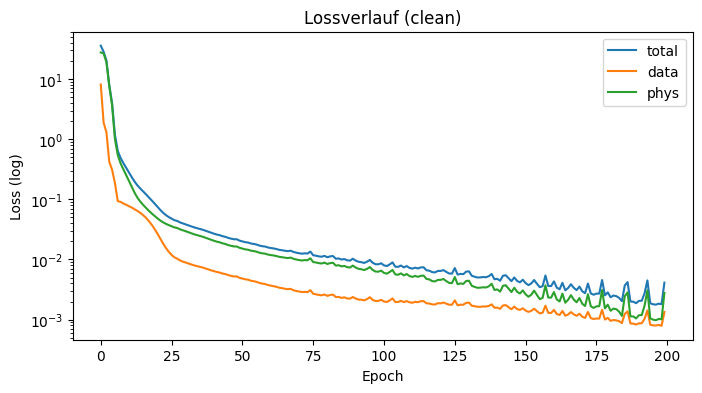

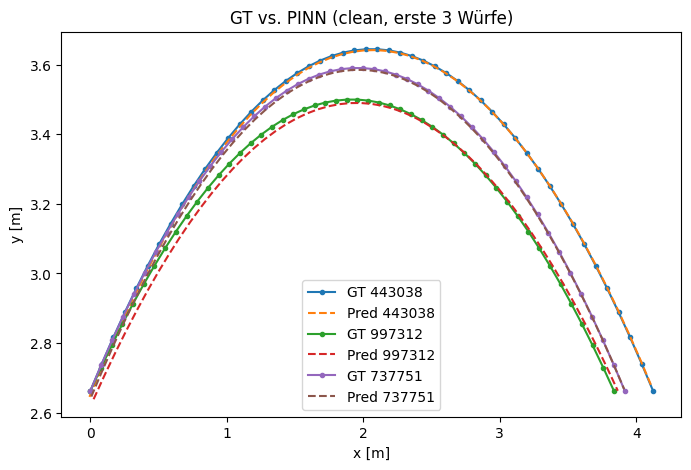

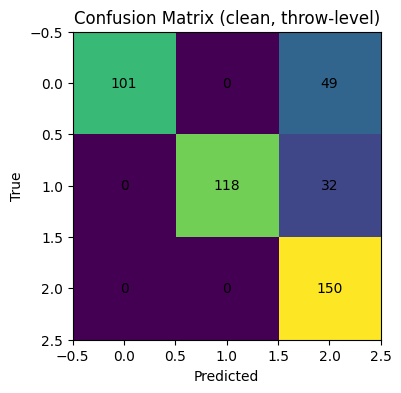

In [6]:
device='cpu'
sim = DataGen(hs=2.13)
params = sim.params if hasattr(sim,'params') else {'l':4.115,'hKorb':3.048,'Rr':0.2286,'Rb':0.1219}
df_clean = sim.generate_dataset(n=150, with_noise=False)
model_clean = FreeThrowPINNModel(hidden_dim=64).to(device)
model_clean, hist_clean, dproc_clean = train_pinn(model_clean, df_clean, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1.0, lambda_phys=1.0, device=device)

plt.figure(figsize=(8,4))
plt.plot(hist_clean['loss'], label='total')
plt.plot(hist_clean['data_loss'], label='data')
plt.plot(hist_clean['phys_loss'], label='phys')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.title('Lossverlauf (clean)')

pred_clean = predict_xy(model_clean, dproc_clean)
ids = pred_clean['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids:
    g_gt = dproc_clean[dproc_clean['wurf_id']==wid].sort_values('t')
    g_pr = pred_clean[pred_clean['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. PINN (clean, erste 3 Würfe)'); plt.legend()

eval_clean = evaluate_throw_level(pred_clean, params)
print('Clean throw-level metrics:')
print('Accuracy=', eval_clean['acc'], ' Precision=', eval_clean['prec'], ' Recall=', eval_clean['rec'], ' F1=', eval_clean['f1'])
cm = eval_clean['cm']
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix (clean, throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha='center', va='center')


## Noisy‑Training (Trajektorie) → Wurfklassifikation aus Vorhersage

Epoch 001 | loss=34.745397 (data=7.436723, phys=27.308674)
Epoch 002 | loss=25.246380 (data=1.645362, phys=23.601018)
Epoch 003 | loss=10.474442 (data=0.820190, phys=9.654252)
Epoch 004 | loss=3.123886 (data=0.543733, phys=2.580153)
Epoch 005 | loss=0.992243 (data=0.234452, phys=0.757791)
Epoch 020 | loss=0.101007 (data=0.047639, phys=0.053368)
Epoch 040 | loss=0.049279 (data=0.027468, phys=0.021811)
Epoch 060 | loss=0.036447 (data=0.024320, phys=0.012128)
Epoch 080 | loss=0.031064 (data=0.023159, phys=0.007905)
Epoch 100 | loss=0.028448 (data=0.022668, phys=0.005781)
Epoch 120 | loss=0.026699 (data=0.022247, phys=0.004452)
Epoch 140 | loss=0.024468 (data=0.021647, phys=0.002821)
Epoch 160 | loss=0.023378 (data=0.021389, phys=0.001989)
Epoch 180 | loss=0.022702 (data=0.021280, phys=0.001422)
Epoch 200 | loss=0.022467 (data=0.021194, phys=0.001272)


C:\Users\luca1\AppData\Local\Temp\ipykernel_21304\2127963107.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pred_labels = pred_df.groupby('wurf_id').apply(lambda g: classify_wurf_from_prediction(g, l, hK, Rr, Rb))


Noisy throw-level metrics:
Accuracy= 0.8333333333333334  Precision= 0.8888888888888888  Recall= 0.8333333333333334  F1= 0.8342920483052332
Vergleich (wurf-level):
     set       acc      prec       rec        f1
0  clean  0.820000  0.883117  0.820000  0.824260
1  noisy  0.833333  0.888889  0.833333  0.834292


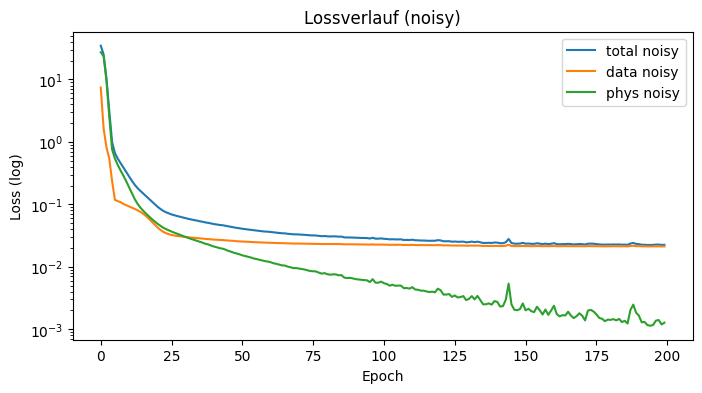

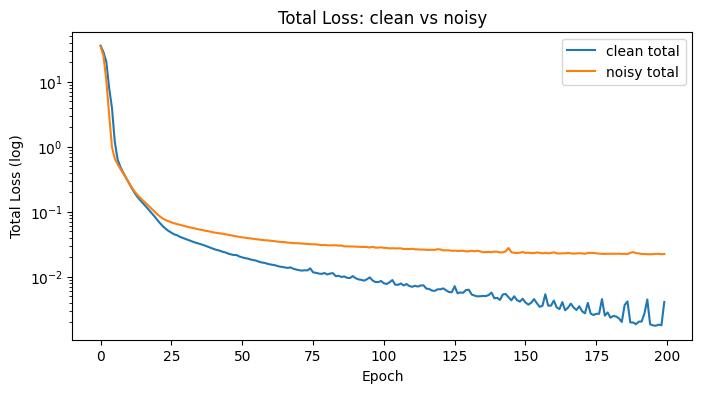

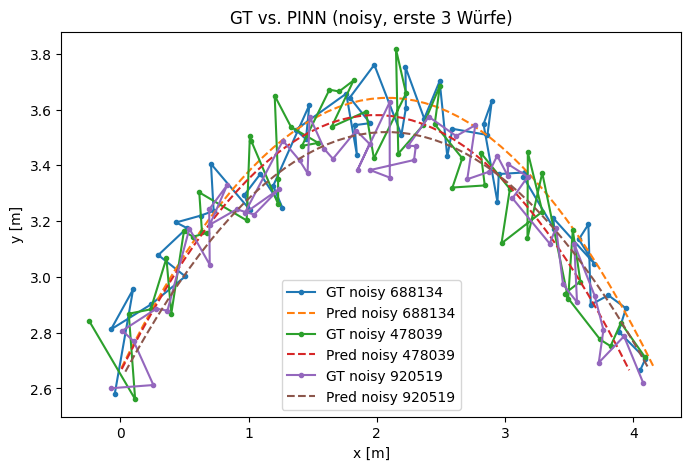

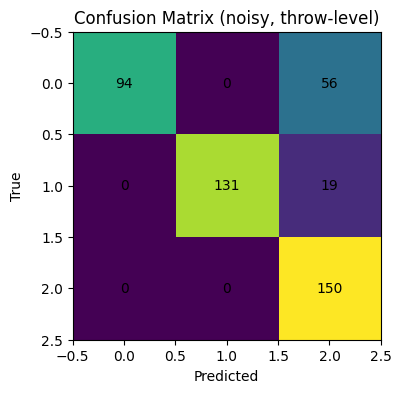

In [7]:
df_noisy = sim.generate_dataset(n=150, with_noise=True)
model_noisy = FreeThrowPINNModel(hidden_dim=64).to(device)
model_noisy, hist_noisy, dproc_noisy = train_pinn(model_noisy, df_noisy, n_epochs=200, batch_size=1024, lr=1e-3, lambda_data=1, lambda_phys=1, device=device)

plt.figure(figsize=(8,4))
plt.plot(hist_noisy['loss'], label='total noisy')
plt.plot(hist_noisy['data_loss'], label='data noisy')
plt.plot(hist_noisy['phys_loss'], label='phys noisy')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Loss (log)'); plt.legend(); plt.title('Lossverlauf (noisy)')

plt.figure(figsize=(8,4))
plt.plot(hist_clean['loss'], label='clean total')
plt.plot(hist_noisy['loss'], label='noisy total')
plt.yscale('log'); plt.xlabel('Epoch'); plt.ylabel('Total Loss (log)'); plt.legend(); plt.title('Total Loss: clean vs noisy')

pred_noisy = predict_xy(model_noisy, dproc_noisy)
ids2 = pred_noisy['wurf_id'].unique()[:3]
plt.figure(figsize=(8,5))
for wid in ids2:
    g_gt = dproc_noisy[dproc_noisy['wurf_id']==wid].sort_values('t')
    g_pr = pred_noisy[pred_noisy['wurf_id']==wid].sort_values('t')
    plt.plot(g_gt['x'], g_gt['y'], marker='.', label=f'GT noisy {wid[:6]}')
    plt.plot(g_pr['x_pred'], g_pr['y_pred'], linestyle='--', label=f'Pred noisy {wid[:6]}')
plt.xlabel('x [m]'); plt.ylabel('y [m]'); plt.title('GT vs. PINN (noisy, erste 3 Würfe)'); plt.legend()

eval_noisy = evaluate_throw_level(pred_noisy, params)
print('Noisy throw-level metrics:')
print('Accuracy=', eval_noisy['acc'], ' Precision=', eval_noisy['prec'], ' Recall=', eval_noisy['rec'], ' F1=', eval_noisy['f1'])
cmn = eval_noisy['cm']
plt.figure(figsize=(5,4))
plt.imshow(cmn)
plt.title('Confusion Matrix (noisy, throw-level)')
plt.xlabel('Predicted'); plt.ylabel('True')
for i in range(cmn.shape[0]):
    for j in range(cmn.shape[1]):
        plt.text(j, i, cmn[i,j], ha='center', va='center')

comp = pd.DataFrame([
    {'set':'clean','acc':eval_clean['acc'],'prec':eval_clean['prec'],'rec':eval_clean['rec'],'f1':eval_clean['f1']},
    {'set':'noisy','acc':eval_noisy['acc'],'prec':eval_noisy['prec'],'rec':eval_noisy['rec'],'f1':eval_noisy['f1']},
])
print('Vergleich (wurf-level):')
print(comp)
